<a href="https://colab.research.google.com/github/Umukundwa004/introduction-to-ml/blob/main/summutive__23_6_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Importing basic libraries
import numpy as np
import tensorflow as tf
import pandas as pd
import os
import random
import shutil
from matplotlib import pyplot
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



# Importing the Keras libraries and packages
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Convolution2D as Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

### downloading dataframe

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessemostipak/hotel-booking-demand")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'hotel-booking-demand' dataset.
Path to dataset files: /kaggle/input/hotel-booking-demand


### loading and check file extension and load accordingly

In [6]:
# set random seeds for reproducibility across runs
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Load the hotel bookings dataset into a pandas DataFrame.
df = pd.read_csv(os.path.join(path, "hotel_bookings.csv"))

# Print the column names of the DataFrame to inspect available features.
print(f"columns:",df.columns)
# display the first 5 rows
df.head()

columns: Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [7]:
#dropping duplicates
df = df.drop_duplicates()
df = df.drop(['reservation_status', 'reservation_status_date'], axis=1)
# Fill missing values (simple strategy)
for col in df.columns:
    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_951/44167465.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_951/44167465.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using '

In [8]:
# Separate numeric and categorical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumeric columns: {numeric_cols}")
print(f"Categorical columns: {categorical_cols}")



Numeric columns: ['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']
Categorical columns: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']


In [9]:
# Encode categorical variables
categorical_cols = df.select_dtypes(include=["object"]).columns

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
print(df.head())

print("\n✓ Preprocessing complete!")


   hotel  is_canceled  lead_time  arrival_date_year  arrival_date_month  \
0      1            0        342               2015                   5   
1      1            0        737               2015                   5   
2      1            0          7               2015                   5   
3      1            0         13               2015                   5   
4      1            0         14               2015                   5   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  \
0                        0                     0       2  ...   
1                        0                     0       2  ...   
2    

### Separate features (X) and target (y)

In [10]:
#sparating features
y = df["is_canceled"]
X = df.drop("is_canceled", axis=1)

In [11]:
X.columns

Index(['hotel', 'lead_time', 'arrival_date_year', 'arrival_date_month',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'meal', 'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests'],
      dtype='object')

data splitting

In [12]:
# Split: 70% train, 15% validation, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
)

print(f"\n" + "="*60)
print("SPLIT DISTRIBUTION")
print("="*60)
print(f"Training:   {len(X_train):3d} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation: {len(X_val):3d} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test:       {len(X_test):3d} samples ({len(X_test)/len(X)*100:.1f}%)")

print(f"\nTarget distribution:")
print(f"Train - Not Placed: {(y_train==0).sum()}, Placed: {(y_train==1).sum()}")
print(f"Test  - Not Placed: {(y_test==0).sum()}, Placed: {(y_test==1).sum()}")



SPLIT DISTRIBUTION
Training:   61211 samples (70.0%)
Validation: 13075 samples (15.0%)
Test:       13110 samples (15.0%)

Target distribution:
Train - Not Placed: 44384, Placed: 16827
Test  - Not Placed: 9506, Placed: 3604


In [13]:
# Standardize features
print(f"\n" + "="*60)
print("STANDARDIZING FEATURES")
print("="*60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)
x_val_scaled = pd.DataFrame(X_val_scaled, columns=X.columns)

print("✓ Features standardized (mean=0, std=1)")
print(f"\nScaled data shapes:")
print(f"  Train: {X_train_scaled.shape}")
print(f"  Test:  {X_test_scaled.shape}")
print(f"  Val:   {X_val_scaled.shape}")

print("\n✓ Data ready for model training!")


STANDARDIZING FEATURES
✓ Features standardized (mean=0, std=1)

Scaled data shapes:
  Train: (61211, 29)
  Test:  (13110, 29)
  Val:   (13075, 29)

✓ Data ready for model training!


logistic regression


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("EXPERIMENT 1: Logistic Regression")
print("-" * 70)
# EXPERIMENT 1: Logistic Regression
# Define and train 'lg_tuned' model using scaled training data
lg_tuned = LogisticRegression(max_iter=1000,random_state=42)
lg_tuned.fit(X_train_scaled, y_train)

# Get predictions and probabilities for scaled model
y_pred_lg = lg_tuned.predict(X_test_scaled) # Hard predictions for classification metrics
y_pred_proba_lg = lg_tuned.predict_proba(X_test_scaled)[:, 1] # Probabilities for ROC curve

# Calculate metrics for scaled model
acc_lg = accuracy_score(y_test, y_pred_lg)
prec_lg = precision_score(y_test, y_pred_lg)
rec_lg = recall_score(y_test, y_pred_lg)
f1_lg = f1_score(y_test, y_pred_lg)

print(f"EXPERIMENT 1b: Logistic Regression ")
print(f"Accuracy:  {acc_lg:.4f}")
print(f"Precision: {prec_lg:.4f}")
print(f"Recall:    {rec_lg:.4f}")
print(f"F1-Score:  {f1_lg:.4f}")
print("-" * 70)

EXPERIMENT 1: Logistic Regression
----------------------------------------------------------------------
EXPERIMENT 1b: Logistic Regression 
Accuracy:  0.7708
Precision: 0.6523
Recall:    0.3560
F1-Score:  0.4606
----------------------------------------------------------------------


In [15]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
# This function plots ROC curves for multiple classification experiments
def plot_multiple_roc_curves(experiments):

    plt.figure(figsize=(8,6))

    for name, y_true, y_prob in experiments:
        # Calculate the False Positive Rate (fpr), True Positive Rate (tpr), and thresholds for the ROC curve.
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        # Calculate the Area Under the Curve (AUC) for the ROC curve, which measures the model's ability to distinguish between classes.
        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            lw=2,
            label=f"{name} (AUC = {roc_auc:.3f})"
        )

    # Plot the random classifier line representing a model
    plt.plot([0,1], [0,1], linestyle='--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves Comparison")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

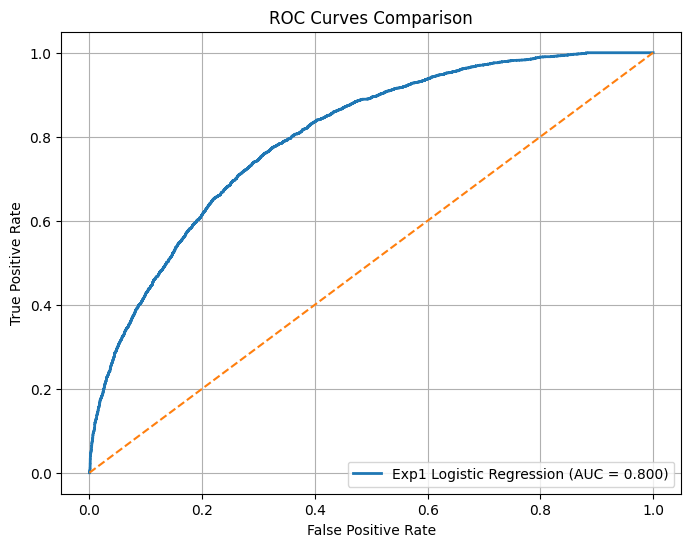

In [16]:
#  Logistic Regression (Exp 1)
plot_multiple_roc_curves([("Exp1 Logistic Regression", y_test, y_pred_proba_lg)])

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("EXPERIMENT 2: decision tree")
print("-" * 70)
# EXPERIMENT 2: decision tree
# Define and train 'dt_model' model using scaled training data
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

# Get predictions and probabilities for scaled model
y_pred_dt = dt_model.predict(X_test_scaled) # Hard predictions for classification metrics
y_pred_proba_dt = dt_model.predict_proba(X_test_scaled)[:, 1] # Probabilities for ROC curve

# Calculate metrics for scaled model
acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print(f"EXPERIMENT 2: Decision Tree ")
print(f"Accuracy:  {acc_dt:.4f}")
print(f"Precision: {prec_dt:.4f}")
print(f"Recall:    {rec_dt:.4f}")
print(f"F1-Score:  {f1_dt:.4f}")
print("-" * 70)

EXPERIMENT 2: decision tree
----------------------------------------------------------------------
EXPERIMENT 2: Decision Tree 
Accuracy:  0.7963
Precision: 0.6284
Recall:    0.6340
F1-Score:  0.6312
----------------------------------------------------------------------


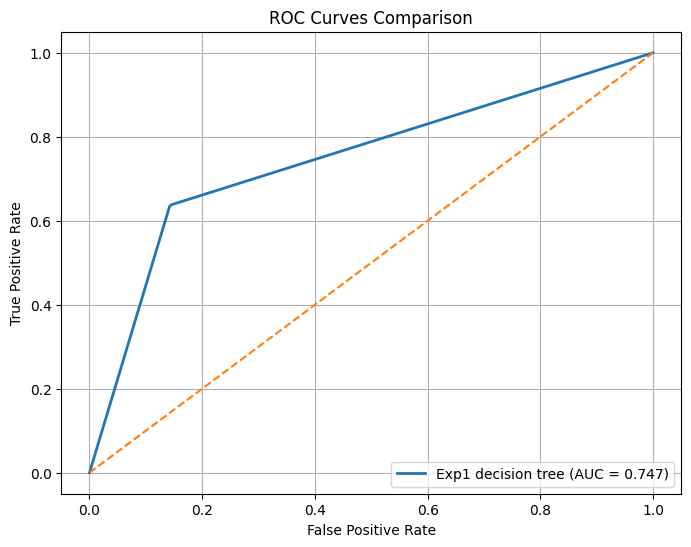

In [18]:
#  decision tree (Exp 2)
plot_multiple_roc_curves([("Exp1 decision tree", y_test, y_pred_proba_dt)])

random forest

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("EXPERIMENT 3: Random Forest ")
print("-" * 70)
# EXPERIMENT 2: random forest
# Define and train 'rf_model' model using scaled training data
rf_model = RandomForestClassifier(n_estimators=100, random_state=42,max_depth=10)
rf_model.fit(X_train_scaled, y_train)
# Making predictions on the scaled test set
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1] # Probabilities for ROC curve

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"Accuracy:  {acc_rf:.4f}")
print(f"Precision: {prec_rf:.4f}")
print(f"Recall:    {rec_rf:.4f}")
print(f"F1-Score:  {f1_rf:.4f}")

EXPERIMENT 3: Random Forest 
----------------------------------------------------------------------
Accuracy:  0.8180
Precision: 0.7809
Recall:    0.4698
F1-Score:  0.5866


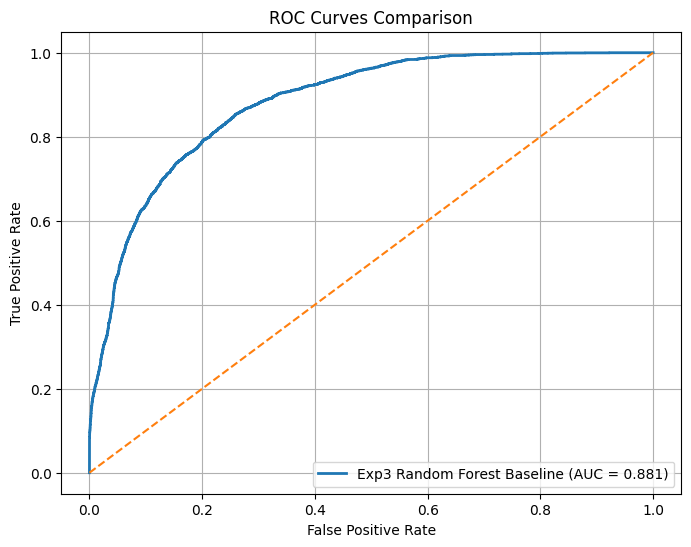

In [20]:
#  Random Forest Baseline (Exp 3)
plot_multiple_roc_curves([("Exp3 Random Forest Baseline", y_test, y_pred_proba_rf)])

In [21]:
print("EXPERIMENT 4: Random Forest (Tuned Hyperparameters)")
print("-" * 70)

# Define the Random Forest Classifier with tuned hyperparameters.
rf_tuned = RandomForestClassifier(n_estimators=150, max_depth=15, min_samples_split=5, random_state=42)
# Train the tuned Random Forest model using the scaled training data.
rf_tuned.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_rf2 = rf_tuned.predict(X_test_scaled)
y_pred_proba_rf2 = rf_tuned.predict_proba(X_test_scaled)[:, 1]# y_pred_proba_rf2: Probability estimates of the positive class for ROC curve analysis.

# Calculate evaluation metrics (Accuracy, Precision, Recall, F1-Score) for the model.
acc_rf2 = accuracy_score(y_test, y_pred_rf2)
prec_rf2 = precision_score(y_test, y_pred_rf2)
rec_rf2 = recall_score(y_test, y_pred_rf2)
f1_rf2 = f1_score(y_test, y_pred_rf2)

print(f"Accuracy:  {acc_rf2:.4f}")
print(f"Precision: {prec_rf2:.4f}")
print(f"Recall:    {rec_rf2:.4f}")
print(f"F1-Score:  {f1_rf2:.4f}")

EXPERIMENT 4: Random Forest (Tuned Hyperparameters)
----------------------------------------------------------------------
Accuracy:  0.8377
Precision: 0.7707
Recall:    0.5830
F1-Score:  0.6638


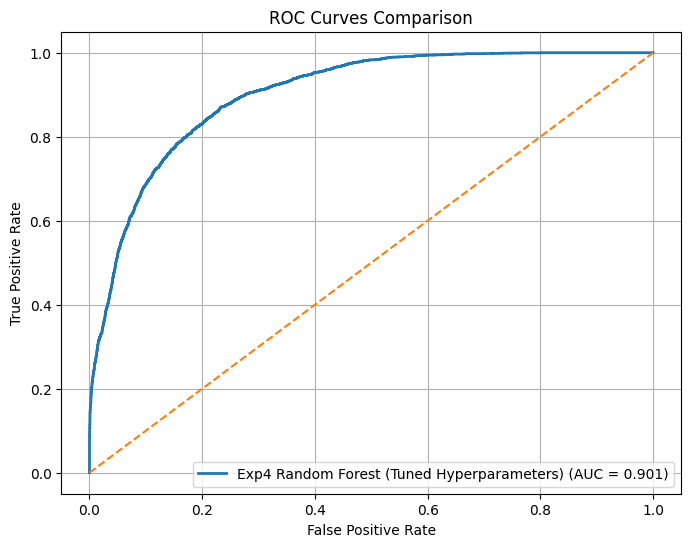

In [22]:
# Random Forest (Tuned Hyperparameters)
plot_multiple_roc_curves([("Exp4 Random Forest (Tuned Hyperparameters)", y_test, y_pred_proba_rf2)])


neural network

In [34]:
import tensorflow.keras as keras
from tensorflow.keras.layers import Dense

print("EXPERIMENT 5: Neural Network (Simple - 2 Hidden Layer)")
print("-" * 70)
# Define a simple sequential neural network model.
# keras.Sequential stacks layers in a linear fashion.
model = keras.Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
# Train the model using the scaled training data and validate with scaled validation data.
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=15,
    batch_size=32,
    verbose=1
)

# Get hard predictions (0s and 1s)
y_pred_nn1 = (model.predict(X_test_scaled) > 0.5).astype("int").flatten()
# Get probability predictions directly from the model
y_pred_proba_nn1 = model.predict(X_test_scaled).flatten()

acc_nn1 = accuracy_score(y_test, y_pred_nn1)
prec_nn1 = precision_score(y_test, y_pred_nn1)
rec_nn1 = recall_score(y_test, y_pred_nn1)
f1_nn1 = f1_score(y_test, y_pred_nn1)

print(f"Accuracy:  {acc_nn1:.4f}")
print(f"Precision: {prec_nn1:.4f}")
print(f"Recall:    {rec_nn1:.4f}")
print(f"F1-Score:  {f1_nn1:.4f}")

EXPERIMENT 5: Neural Network (Simple - 2 Hidden Layer)
----------------------------------------------------------------------
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1913/1913 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7935 - loss: 0.4367 - val_accuracy: 0.8073 - val_loss: 0.4061
Epoch 2/15
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8106 - loss: 0.3991 - val_accuracy: 0.8149 - val_loss: 0.3907
Epoch 3/15
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8165 - loss: 0.3848 - val_accuracy: 0.8190 - val_loss: 0.3820
Epoch 4/15
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8214 - loss: 0.3752 - val_accuracy: 0.8208 - val_loss: 0.3775
Epoch 5/15
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8245 - loss: 0.3692 - val_accuracy: 0.8235 - val_loss: 0.3748
Epoch 6/15
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8277 - loss: 0.3646 - val_accuracy: 0.8233 - val_loss: 0.3728
Epoch 7/15
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8297 - loss: 0.3610 - val_accuracy: 0.8238 - val_loss: 0.3715
Epoch 8/15
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8311 - loss: 0.3579 - val_accura

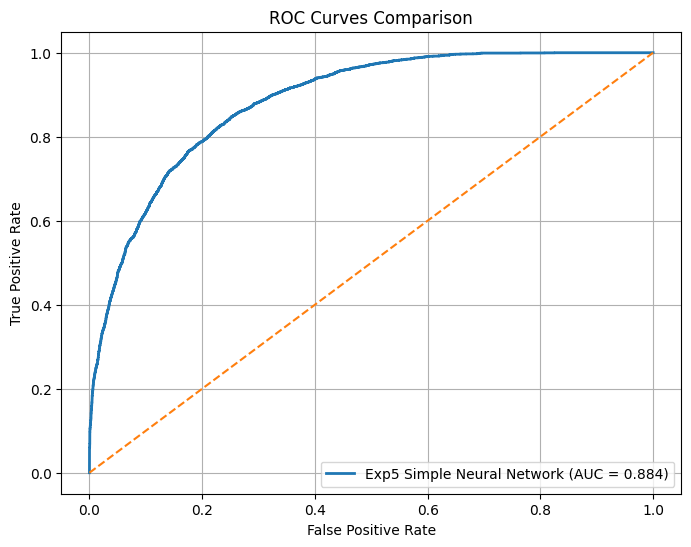

In [35]:
# NN Simple (Exp 5)
plot_multiple_roc_curves([("Exp5 Simple Neural Network", y_test, y_pred_proba_nn1)])

##improved cnn with dropouts


In [36]:
# EXPERIMENT 6: Neural Network with dropouts
# This experiment explores a deeper neural network architecture incorporating with Dropout layers
print("EXPERIMENT 6: Neural Network (Deeper with Dropout)")
print("-" * 70)
from tensorflow.keras.layers import Dropout
# keras.Sequential stacks layers in a linear fashion.
model2 = keras.Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
# Compile the model
model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
# Train the model
history2 = model2.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)
# Make predictions on the scaled test set
y_pred_nn2 = (model2.predict(X_test_scaled, verbose=0) > 0.5).astype(int).flatten()
# Get probability predictions directly from the model
y_pred_proba_nn2 = model2.predict(X_test_scaled).flatten()
# Calculate evaluation metrics for the model on the test set
acc_nn2 = accuracy_score(y_test, y_pred_nn2)
prec_nn2 = precision_score(y_test, y_pred_nn2)
rec_nn2 = recall_score(y_test, y_pred_nn2)
f1_nn2 = f1_score(y_test, y_pred_nn2)
print(f"Accuracy:  {acc_nn2:.4f}")
print(f"Precision: {prec_nn2:.4f}")
print(f"Recall:    {rec_nn2:.4f}")
print(f"F1-Score:  {f1_nn2:.4f}")

EXPERIMENT 6: Neural Network (Deeper with Dropout)
----------------------------------------------------------------------
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1913/1913 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7797 - loss: 0.4582 - val_accuracy: 0.8069 - val_loss: 0.4131
Epoch 2/20
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8008 - loss: 0.4207 - val_accuracy: 0.8123 - val_loss: 0.3951
Epoch 3/20
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8093 - loss: 0.4031 - val_accuracy: 0.8182 - val_loss: 0.3845
Epoch 4/20
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8129 - loss: 0.3942 - val_accuracy: 0.8221 - val_loss: 0.3783
Epoch 5/20
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8167 - loss: 0.3893 - val_accuracy: 0.8239 - val_loss: 0.3750
Epoch 6/20
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8192 - loss: 0.3833 - val_accuracy: 0.8258 - val_loss: 0.3726
Epoch 7/20
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8204 - loss: 0.3811 - val_accuracy: 0.8252 - val_loss: 0.3708
Epoch 8/20
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8223 - loss: 0.3785 - val_accu

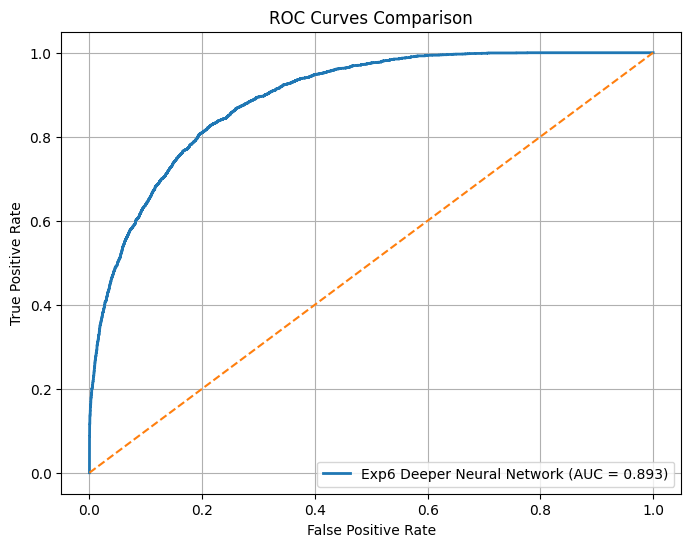

In [37]:
#  NN Deeper (Exp 6)
plot_multiple_roc_curves([("Exp6 Deeper Neural Network", y_test, y_pred_proba_nn2)])

In [38]:
# This experiment introduces Batch Normalization layers to improve training stability and performance.
# EXPERIMENT 7: Neural Network with Batch Normalization
# This experiment explores a deeper neural network architecture incorporating Batch Normalization and Dropout layers
print("EXPERIMENT 7: Neural Network (Batch Norm)")
print("-" * 70)
import tensorflow.keras as keras
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping
#
model3 = keras.Sequential([
    Dense(128, activation='relu',input_shape=(X_train.shape[1],)),
    BatchNormalization(), # This normalizes the activations of the previous layer, helping stabilize and speed up training.
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
# Compile the model
model3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
# This callback monitors a specified metric (validation loss in this case) and stops training if it stops improving
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
# Train the model using the scaled training data and validate with scaled validation data.
history3 = model3.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=[early_stop]
)
# Make predictions on the scaled test set
y_pred_nn3 = (model3.predict(X_test_scaled, verbose=0) > 0.5).astype(int).flatten()
y_pred_proba_nn3 = model3.predict(X_test_scaled).flatten()
# Calculate evaluation metrics for the model on the test set
acc_nn3 = accuracy_score(y_test, y_pred_nn3)
prec_nn3 = precision_score(y_test, y_pred_nn3)
rec_nn3 = recall_score(y_test, y_pred_nn3)
f1_nn3 = f1_score(y_test, y_pred_nn3)
# Print the calculated metrics
print(f"Accuracy:  {acc_nn3:.4f}")
print(f"Precision: {prec_nn3:.4f}")
print(f"Recall:    {rec_nn3:.4f}")
print(f"F1-Score:  {f1_nn3:.4f}")

EXPERIMENT 7: Neural Network (Batch Norm)
----------------------------------------------------------------------
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1913/1913 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.7707 - loss: 0.4756 - val_accuracy: 0.8051 - val_loss: 0.4220
Epoch 2/100
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7942 - loss: 0.4307 - val_accuracy: 0.8135 - val_loss: 0.4028
Epoch 3/100
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8021 - loss: 0.4155 - val_accuracy: 0.8156 - val_loss: 0.3945
Epoch 4/100
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8062 - loss: 0.4068 - val_accuracy: 0.8197 - val_loss: 0.3882
Epoch 5/100
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8097 - loss: 0.3994 - val_accuracy: 0.8220 - val_loss: 0.3842
Epoch 6/100
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8128 - loss: 0.3947 - val_accuracy: 0.8230 - val_loss: 0.3810
Epoch 7/100
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8150 - loss: 0.3905 - val_accuracy: 0.8255 - val_loss: 0.3769
Epoch 8/100
1913/1913 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8147 - loss: 0.3883 - val

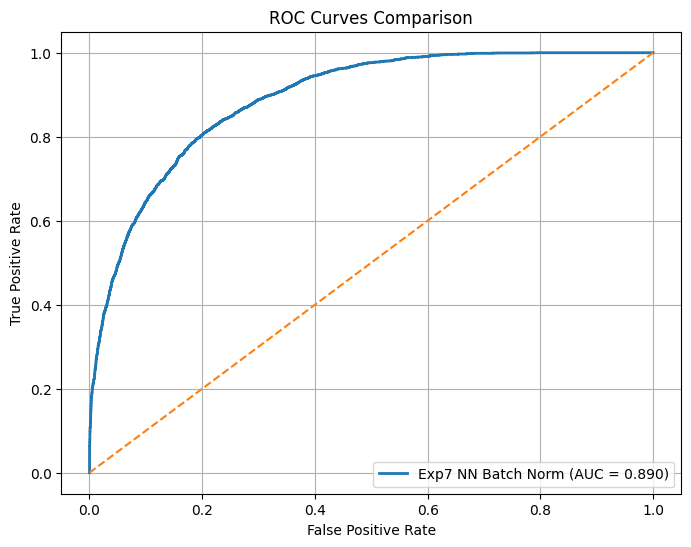

In [39]:
# NN Batch Norm (Exp 7)
plot_multiple_roc_curves([("Exp7 NN Batch Norm", y_test, y_pred_proba_nn3)])

confusin matrix

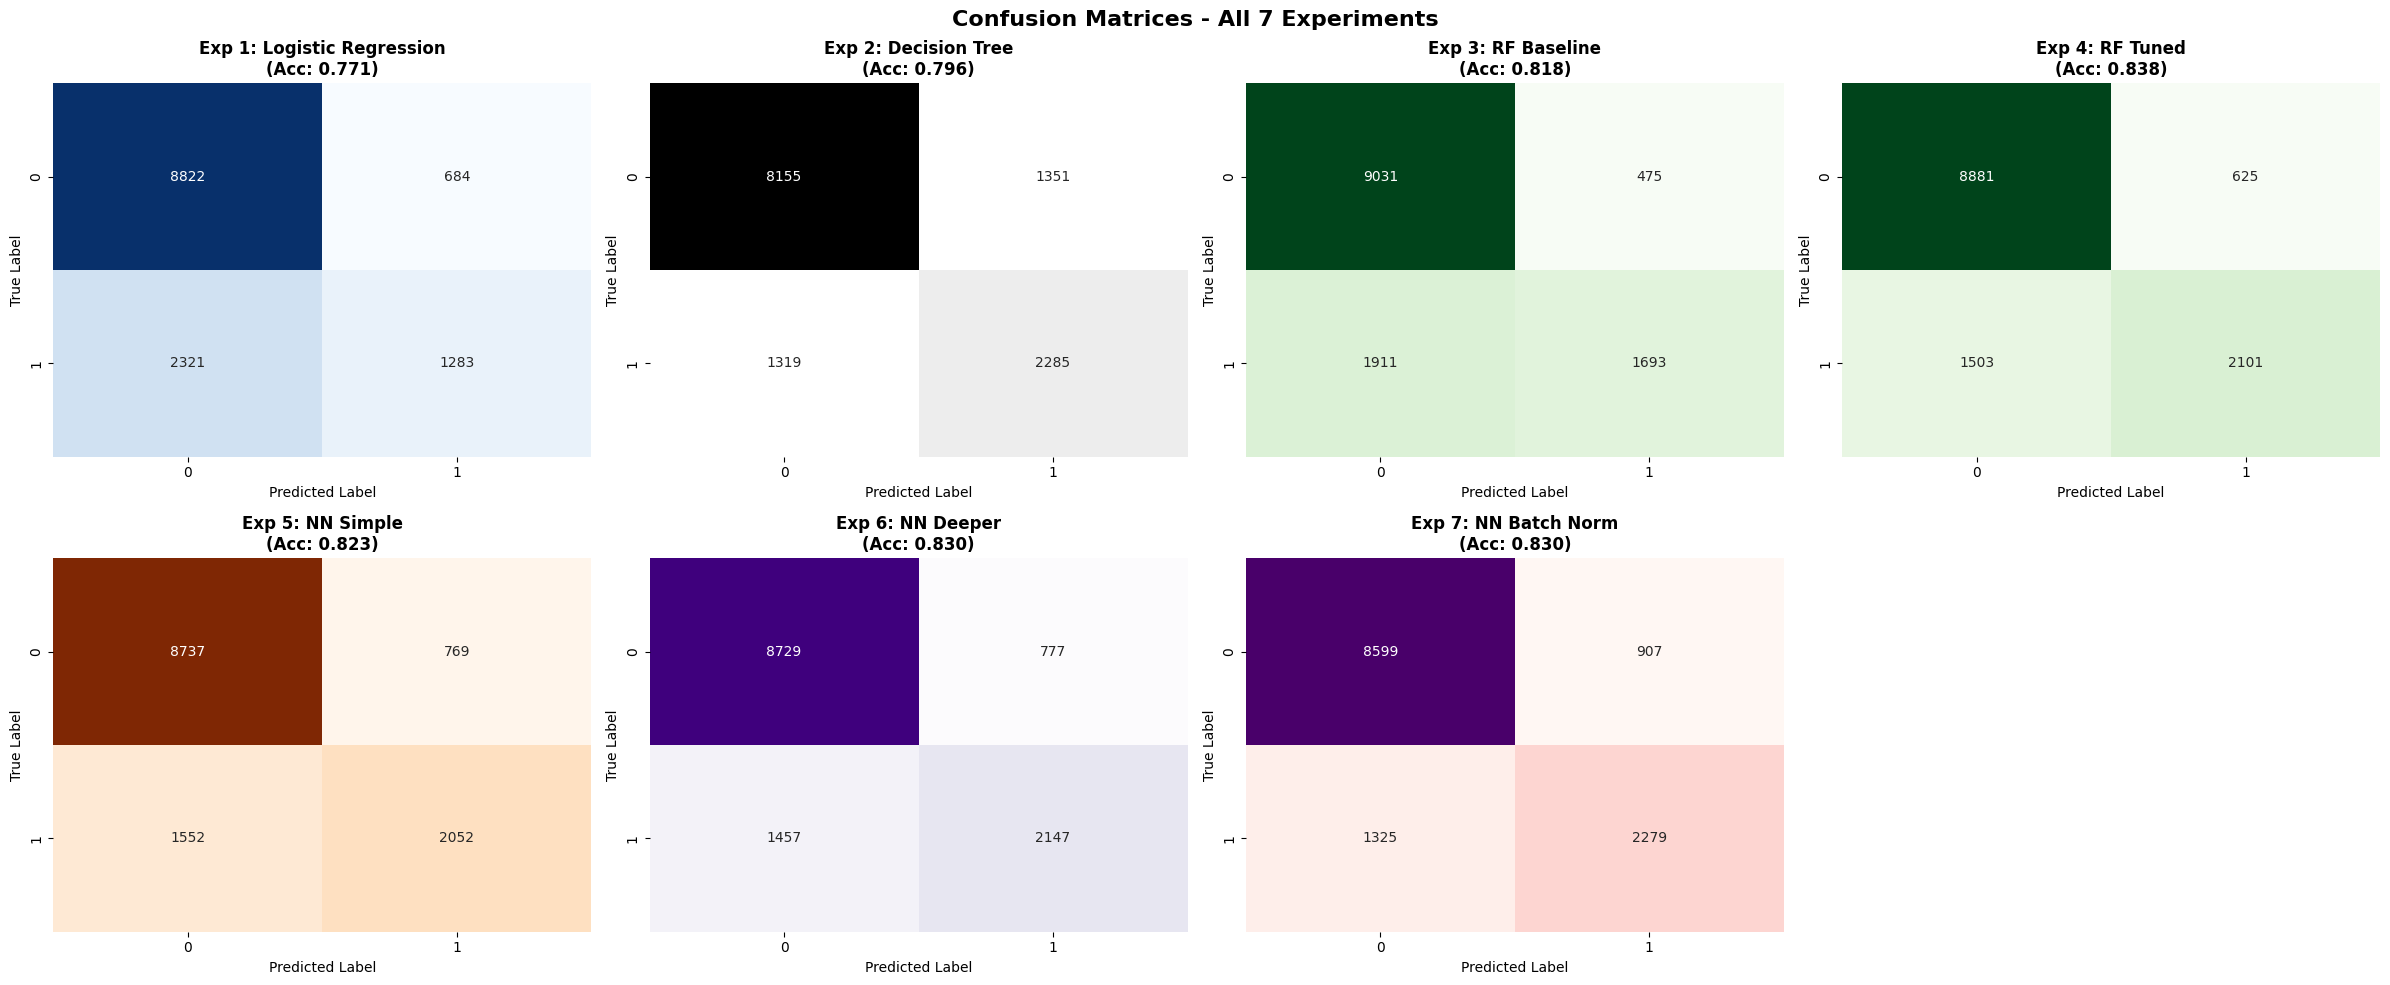

✓ Confusion matrices saved as 'confusion_matrices.png'



In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(24, 10)) # Adjusted to 2 rows, 4 columns for 7 experiments
fig.suptitle('Confusion Matrices - All 7 Experiments', fontsize=16, fontweight='bold')

# Flatten axes for easier indexing
axes = axes.flatten()

cm_list = [
    (confusion_matrix(y_test, y_pred_lg), f'Exp 1: Logistic Regression\n(Acc: {acc_lg:.3f})', 'Blues'),
    (confusion_matrix(y_test, y_pred_dt), f'Exp 2: Decision Tree\n(Acc: {acc_dt:.3f})', 'Greys'),
    (confusion_matrix(y_test, y_pred_rf), f'Exp 3: RF Baseline\n(Acc: {acc_rf:.3f})', 'Greens'),
    (confusion_matrix(y_test, y_pred_rf2), f'Exp 4: RF Tuned\n(Acc: {acc_rf2:.3f})', 'Greens'),
    (confusion_matrix(y_test, y_pred_nn1), f'Exp 5: NN Simple\n(Acc: {acc_nn1:.3f})', 'Oranges'),
    (confusion_matrix(y_test, y_pred_nn2), f'Exp 6: NN Deeper\n(Acc: {acc_nn2:.3f})', 'Purples'),
    (confusion_matrix(y_test, y_pred_nn3), f'Exp 7: NN Batch Norm\n(Acc: {acc_nn3:.3f})', 'RdPu')

]

for i, (cm, title, cmap) in enumerate(cm_list):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes[i], cbar=False)
    axes[i].set_title(title, fontweight='bold')
    axes[i].set_ylabel('True Label')
    axes[i].set_xlabel('Predicted Label')

# Remove any unused subplots if the total number of subplots exceeds the number of experiments
for i in range(len(cm_list), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Confusion matrices saved as 'confusion_matrices.png'\n")

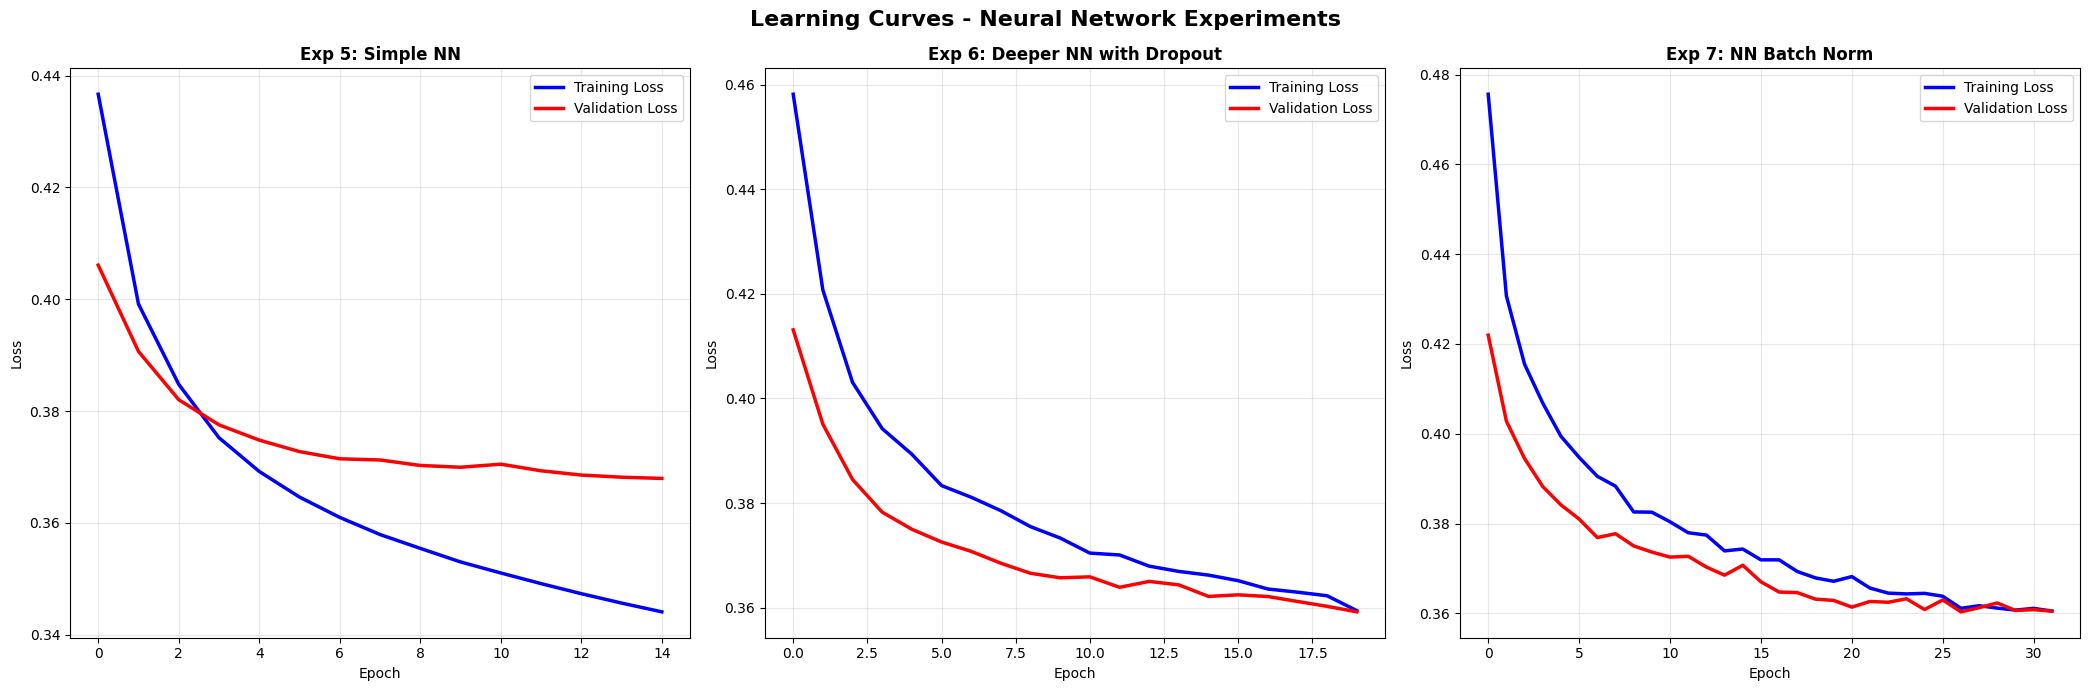

✓ Learning curves saved as 'learning_curves.png'



In [41]:
import numpy as np # Import numpy for np.ndarray check
import matplotlib.pyplot as plt # Ensure plt is imported

# Create a figure and a set of subplots for visualizing the learning curves of each neural network experiment.
fig, axes = plt.subplots(1, 3, figsize=(21, 7)) # Changed to 3 subplots
fig.suptitle('Learning Curves - Neural Network Experiments', fontsize=16, fontweight='bold')
learning_curves = [
    (history, 'Exp 5: Simple NN'),
    (history2, 'Exp 6: Deeper NN with Dropout'), # Corrected typo and description
    (history3, 'Exp 7: NN Batch Norm'),
]
if not isinstance(axes, np.ndarray):
    axes = [axes]

for i, (hist_obj, title) in enumerate(learning_curves):
    ax = axes[i]
    # Plot the training loss over epochs.
    ax.plot(hist_obj.history['loss'], label='Training Loss', linewidth=2.5, color='blue')
    ax.plot(hist_obj.history['val_loss'], label='Validation Loss', linewidth=2.5, color='red')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Loss')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Adjust subplot parameters for a tight layout, preventing overlap.
plt.tight_layout()
# Save the generated figure of learning curves to a file.
plt.savefig('learning_curves.png', dpi=300, bbox_inches='tight')
# Display the plot.
plt.show()
print("✓ Learning curves saved as 'learning_curves.png'\n")

In [43]:
import pandas as pd
import matplotlib.pyplot as plt # Import matplotlib for saving figures

# created a DataFrame to  display the evaluation results of all trained models.
# This table provides a clear overview of each model's performance metrics, hyperparameters, and key observations.
results = pd.DataFrame({
    "Model": [
        "exp1:Logistic Regression",
        "exp2:Decision Tree",
        "exp3:Random Forest Baseline",
        "exp4:Random Forest Tuned",
        "exp5:NN Simple",
        "exp6: Deeper NN with Dropout",
        "exp7:NN Batch Norm"
    ],
    "Accuracy": [ acc_lg, acc_dt, acc_rf, acc_rf2, acc_nn1, acc_nn2, acc_nn3 ], # Overall correctness of predictions.
    "Precision": [prec_lg, prec_dt, prec_rf, prec_rf2, prec_nn1, prec_nn2, prec_nn3 ], # Proportion of positive identifications that were actually correct.
    "Recall": [rec_lg, rec_dt, rec_rf, rec_rf2, rec_nn1, rec_nn2, rec_nn3 ], # Proportion of actual positives that were identified correctly.
    "F1-Score": [f1_lg, f1_dt, f1_rf, f1_rf2, f1_nn1, f1_nn2, f1_nn3 ], # Harmonic mean of precision and recall.
    "Hyperparameters": [
        "max_iter=1000",
        "max_depth=None, min_samples_leaf=1",
        "n_estimators=100, max_depth=10",
        "n_estimators=150, max_depth=15, min_samples_split=5",
        "2 Dense layers (64, 32 neurons)",
        "3 Dense layers (128, 64, 32 neurons) with 2 Dropout(0.3) layers",
        "3 Dense layers with Batch Norm, 2 Dropout(0.3) layers, EarlyStopping(patience=5)"
    ],
    "Observations": [
        "Basic linear model, serves as a performance baseline.",
        "Performs well, particularly in recall, suggesting good capture of positive cases. Simpler than Random Forest.",
        "Significant improvement over Logistic Regression, good precision.",
        "Best F1-Score among tree-based models, improved recall with tuning.",
        "Solid performance, comparable to RF baseline in F1.",
        "Deeper architecture with dropout improved generalization and recall over simple NN.",
        "Achieved the highest recall among NN models, Batch Norm aided stability and performance."
    ]
})

display(results)

# Create a matplotlib figure and an axes object
fig, ax = plt.subplots(figsize=(12, 4)) # Adjust figure size as needed
ax.axis('off') # Turn off the axis ticks and labels

# Plot the DataFrame as a table on the axes
# bbox=[0, 0, 1, 1] fills the entire figure area
table = ax.table(cellText=results.values,
                 colLabels=results.columns,
                 loc='center',
                 cellLoc='left') # Align cell text to the left for readability

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2) # Adjust table scale as needed

# Save the figure
plt.savefig('result_table.png', dpi=300, bbox_inches='tight')
plt.close(fig) # Close the figure to avoid displaying it twice (once as table, once as image)
print("Result table saved as 'result_table.png'")

,Model,Accuracy,Precision,Recall,F1-Score,Hyperparameters,Observations
0,exp1:Logistic Regression,0.770786,0.652262,0.355993,0.460600,max_iter=1000,"Basic linear model, serves as a performance ba..."
1,exp2:Decision Tree,0.796339,0.628438,0.634018,0.631215,"max_depth=None, min_samples_leaf=1","Performs well, particularly in recall, suggest..."
2,exp3:Random Forest Baseline,0.818002,0.780904,0.469756,0.586625,"n_estimators=100, max_depth=10",Significant improvement over Logistic Regressi...
3,exp4:Random Forest Tuned,0.837681,0.770726,0.582963,0.663823,"n_estimators=150, max_depth=15, min_samples_sp...","Best F1-Score among tree-based models, improve..."
4,exp5:NN Simple,0.822960,0.727402,0.569367,0.638755,"2 Dense layers (64, 32 neurons)","Solid performance, comparable to RF baseline i..."
5,exp6: Deeper NN with Dropout,0.829596,0.734268,0.595727,0.657782,"3 Dense layers (128, 64, 32 neurons) with 2 Dr...",Deeper architecture with dropout improved gene...
6,exp7:NN Batch Norm,0.829748,0.715317,0.632353,0.671281,"3 Dense layers with Batch Norm, 2 Dropout(0.3)...","Achieved the highest recall among NN models, B..."


Result table saved as 'result_table.png'


In [42]:
import joblib

# Assuming rf_tuned is the best model based on F1-Score from previous analysis
# Save the best model
joblib.dump(rf_tuned, 'best_model_rf_tuned.joblib')

print("Best model (Random Forest Tuned) saved as 'best_model_rf_tuned.joblib'")

Best model (Random Forest Tuned) saved as 'best_model_rf_tuned.joblib'
